# **Projet 1 : Deep Convolutional GAN (DCGAN)**

## **Introduction**

Ce projet vise à concevoir et entraîner un modèle génératif (DCGAN) sur le dataset Quick Draw "Sheep" (Moutons). L'objectif est de générer de nouvelles illustrations réalistes en apprenant la distribution des données originales via une compétition entre un Générateur et un Discriminateur.

## 1. Configuration et Imports des Modules
Montage du Drive et ajout du dossier project_ au système pour permettre l'importation des modules personnels.

In [28]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Montage du Drive
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Définition des chemins
PROJECT_DIR = '/content/drive/MyDrive/project_'
DATA_PATH   = os.path.join(PROJECT_DIR, 'QuickDraw/origine/sheep.npy')
RUN_DIR     = os.path.join(PROJECT_DIR, 'run_dcgan')

# 3. Ajout du dossier projet au path pour importer vos modules
sys.path.append(PROJECT_DIR)

# 4. Importation de vos modules personnalisés
try:
    from modules.models.DCGAN import DCGAN
    from modules.callbacks.ImagesCallback import ImagesCallback
    print(" Modules DCGAN et ImagesCallback importés avec succès.")
except ImportError as e:
    print(f" Erreur d'import : {e}")
    print("Vérifiez que les fichiers __init__.py existent ou que la structure est correcte.")

 Modules DCGAN et ImagesCallback importés avec succès.


## 2. Paramètres du Projet

Définition des hyperparamètres selon

In [29]:
# Paramètres
LATENT_DIM = 128
SCALE      = 0.3     # 0.1 pour tester rapidement, 1.0 pour le résultat final
EPOCHS     = 40      # Augmenter pour améliorer la qualité
BATCH_SIZE = 64      # batch plus grand = gradients plus stables
NUM_IMG    = 12      # Images à visualiser
VERBOSITY  = 1

print(f"Config : Scale={SCALE}, Epochs={EPOCHS}, Latent={LATENT_DIM}")

Config : Scale=0.3, Epochs=40, Latent=128


## 3. Chargement et Préparation des Données
Chargement des moutons, normalisation et visualisation

Données brutes : 126121 images.
Données d'entraînement : (37836, 28, 28, 1)

--- Exemples du dataset (Normalisés) ---


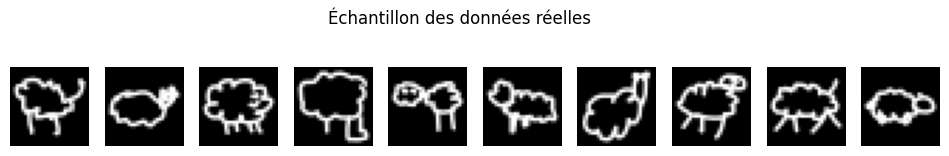

In [30]:
# Chargement
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH}")

raw_data = np.load(DATA_PATH)
print(f"Données brutes : {len(raw_data)} images.")

# Sous-échantillonnage et Reshape
n_samples = int(len(raw_data) * SCALE)
x_train = raw_data[:n_samples]
x_train = x_train.reshape(-1, 28, 28, 1)

# Normalisation [0, 1] (Car sortie Générateur = Sigmoid)
x_train = x_train.astype('float32') / 255.0

print(f"Données d'entraînement : {x_train.shape}")

# Visualisation (Fond noir standard)
print("\n--- Exemples du dataset (Normalisés) ---")
plt.figure(figsize=(12, 2))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis("off")
plt.suptitle("Échantillon des données réelles")
plt.show()

# Création du tf.Dataset
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

## 4. Modélisation (Générateur et Discriminateur)
Construction du Générateur et du Discriminateur avec la Keras Functional API en respectant les consignes (Sigmoid finale pour le générateur).

In [31]:
def build_generator(latent_dim):
    """Architecture : Dense -> Reshape -> Upsample -> Conv -> Conv (Sigmoid)"""
    inputs = keras.Input(shape=(latent_dim,))

    # Dense -> Reshape (7x7)
    x = layers.Dense(7 * 7 * 128, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((7, 7, 128))(x)

    # Upsample x2 (14x14)
    x = layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Upsample x2 (28x28)
    x = layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Sortie finale + Sigmoid
    outputs = layers.Conv2D(1, (5, 5), padding='same', activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name="generator")

def build_discriminator():
    """Architecture : 3 Convs (stride 2) -> Flatten -> Dense (Sigmoid)"""
    inputs = keras.Input(shape=(28, 28, 1))

    # Conv 1
    x = layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same')(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Conv 2
    x = layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Conv 3
    x = layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Flatten & Output
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name="discriminator")

# Instanciation
generator = build_generator(LATENT_DIM)
discriminator = build_discriminator()
print("Architectures définies.")

Architectures définies.


## 5. Entraînement (Classe DCGAN)
Utilisation de la classe DCGAN importée des modules et du callback ImagesCallback

In [32]:
# 1. Instanciation du modèle global
dcgan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

# 2. Compilation
dcgan.compile(
    discriminator_optimizer=keras.optimizers.Adam(learning_rate=0.00005, beta_1=0.5),
    generator_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_function=keras.losses.BinaryCrossentropy()
)

# 3. Préparation du Callback
callback_img = ImagesCallback(num_img=NUM_IMG, latent_dim=LATENT_DIM, run_dir=RUN_DIR)

# 4. Lancement de l'entraînement
print(f"Lancement de l'entraînement pour {EPOCHS} epochs...")
history = dcgan.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[callback_img],
    verbose=VERBOSITY
)

# 5. Sauvegarde du modèle
save_path = os.path.join(RUN_DIR, 'models', 'dcgan_final')
dcgan.save(save_path)
print(f"Modèles sauvegardés dans {save_path}")

Fidle DCGAN is ready :-)  latent dim = 128
Lancement de l'entraînement pour 40 epochs...
Epoch 1/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - d_loss: 0.2808 - g_loss: 2.1706
Epoch 2/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - d_loss: 0.0035 - g_loss: 5.5158
Epoch 3/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - d_loss: 0.0013 - g_loss: 6.7496
Epoch 4/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - d_loss: 0.0018 - g_loss: 7.2811
Epoch 5/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - d_loss: 9.1438e-04 - g_loss: 7.6226
Epoch 6/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - d_loss: 5.4040e-04 - g_loss: 8.2759
Epoch 7/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - d_loss: 0.1955 - g_loss: 6.3204
Epoch 8/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - d_loss: 0.4980 - g_loss: 1.3689
Epoch 9/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - d_loss: 0.5122 - g_loss: 1.2670
Epoch 10/40
592/592 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - d_loss: 0.5777 - g_loss: 1.0350
Epoch 11/40
592/592 ━━

Modèles sauvegardés dans /content/drive/MyDrive/project_/run_dcgan/models/dcgan_final


Génération des images finales...


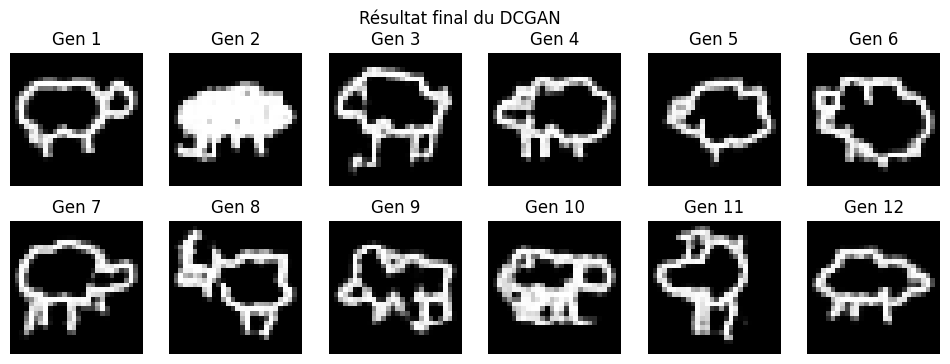

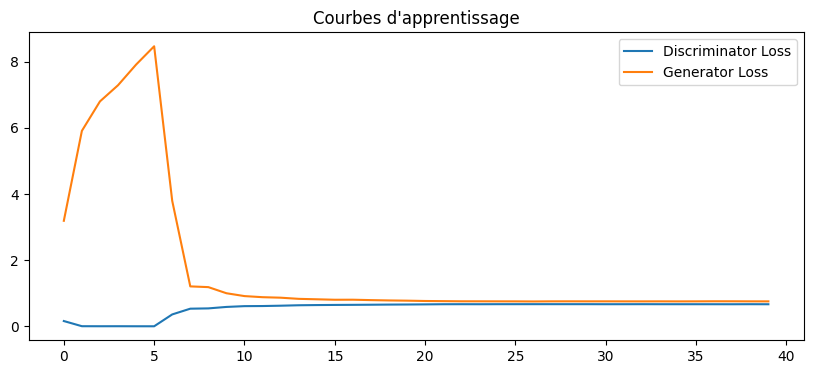

In [33]:
# Génération
print("Génération des images finales...")
random_latent_vectors = tf.random.normal(shape=(NUM_IMG, LATENT_DIM))
generated_images = generator(random_latent_vectors)

# Affichage
plt.figure(figsize=(12, 4))
for i in range(NUM_IMG):
    ax = plt.subplot(2, 6, i + 1)
    img = generated_images[i].numpy().squeeze()
    # Visualisation standard (fond noir, trait blanc)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Gen {i+1}")

plt.suptitle("Résultat final du DCGAN")
plt.show()

# Affichage des courbes de Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['d_loss'], label='Discriminator Loss')
plt.plot(history.history['g_loss'], label='Generator Loss')
plt.title("Courbes d'apprentissage")
plt.legend()
plt.show()
